# StreamLoop — Tuning the Churn Model

StreamLoop's customer data is publicly modeled after the IBM Telco Customer Churn dataset.
This notebook loads that CSV **directly from URL**, builds a baseline classifier, then tunes
hyperparameters with `RandomizedSearchCV`.

**Target:** `Churn` (`Yes` / `No`)  
**Features:** customer account, service, and billing attributes


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid")

DATA_URL = (
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
    "master/data/Telco-Customer-Churn.csv"
)
RANDOM_STATE = 42


## 1. Load data from URL

In [2]:
df = pd.read_csv(DATA_URL)
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()
print("\nChurn value counts:")
print(df["Churn"].value_counts(normalize=True).round(3))


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Clean & prepare features

In [4]:
clean = df.copy()
clean["TotalCharges"] = pd.to_numeric(clean["TotalCharges"], errors="coerce")
clean["TotalCharges"] = clean["TotalCharges"].fillna(clean["TotalCharges"].median())
clean["Churn"] = (clean["Churn"] == "Yes").astype(int)

y = clean["Churn"]
X = clean.drop(columns=["Churn", "customerID"])

print(f"features={X.shape[1]} churn_rate={y.mean():.3f}")
X.head()


features=19 churn_rate=0.265


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


## 3. Quick EDA

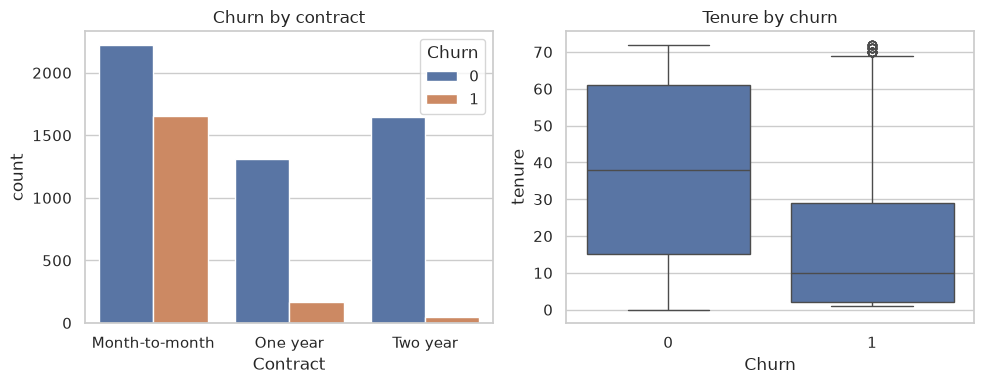

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=clean, x="Contract", hue="Churn", ax=axes[0])
axes[0].set_title("Churn by contract")
sns.boxplot(data=clean, x="Churn", y="tenure", ax=axes[1])
axes[1].set_title("Tenure by churn")
plt.tight_layout()
plt.show()


## 4. Train / test split + baseline model

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

def make_pipeline():
    return Pipeline(
        steps=[
            ("preprocess", preprocess),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=100,
                    random_state=RANDOM_STATE,
                    class_weight="balanced",
                    n_jobs=-1,
                ),
            ),
        ]
    )

def evaluate(pipe, X_te, y_te):
    y_pred = pipe.predict(X_te)
    y_proba = pipe.predict_proba(X_te)[:, 1]
    return {
        "accuracy": float(accuracy_score(y_te, y_pred)),
        "precision": float(precision_score(y_te, y_pred)),
        "recall": float(recall_score(y_te, y_pred)),
        "f1": float(f1_score(y_te, y_pred)),
        "roc_auc": float(roc_auc_score(y_te, y_proba)),
    }

baseline = make_pipeline()
baseline.fit(X_train, y_train)
baseline_metrics = evaluate(baseline, X_test, y_test)
baseline_metrics


{'accuracy': 0.7672107877927609,
 'precision': 0.5534883720930233,
 'recall': 0.6363636363636364,
 'f1': 0.5920398009950248,
 'roc_auc': 0.817430055025963}

## 5. Hyperparameter tuning

`RandomizedSearchCV` over RandomForest hyperparameters, optimizing **ROC-AUC** with 5-fold stratified CV.


In [7]:
param_distributions = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 8, 12, 16],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    make_pipeline(),
    param_distributions=param_distributions,
    n_iter=12,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", round(float(search.best_score_), 4))

tuned_metrics = evaluate(search.best_estimator_, X_test, y_test)
tuned_metrics


Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best params: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 8}
Best CV ROC-AUC: 0.8473


{'accuracy': 0.7537260468417317,
 'precision': 0.5238095238095238,
 'recall': 0.7941176470588235,
 'f1': 0.6312433581296493,
 'roc_auc': 0.8432819241003385}

## 6. Compare baseline vs tuned

,accuracy,precision,recall,f1,roc_auc
baseline,0.7672,0.5535,0.6364,0.5920,0.8174
tuned,0.7537,0.5238,0.7941,0.6312,0.8433


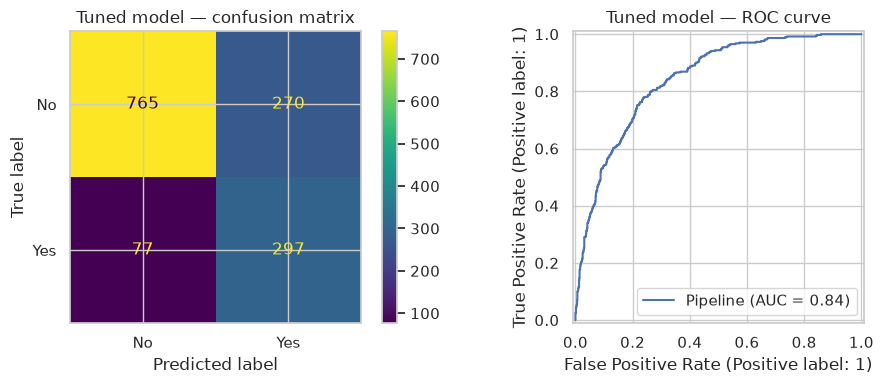

              precision    recall  f1-score   support

          No       0.91      0.74      0.82      1035
         Yes       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



In [8]:
comparison = pd.DataFrame(
    {"baseline": baseline_metrics, "tuned": tuned_metrics}
).T
display(comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_estimator(
    search.best_estimator_, X_test, y_test, display_labels=["No", "Yes"], ax=axes[0]
)
axes[0].set_title("Tuned model — confusion matrix")
RocCurveDisplay.from_estimator(search.best_estimator_, X_test, y_test, ax=axes[1])
axes[1].set_title("Tuned model — ROC curve")
plt.tight_layout()
plt.show()

print(classification_report(
    y_test,
    search.best_estimator_.predict(X_test),
    target_names=["No", "Yes"],
))


In [9]:
payload = {
    "data_url": DATA_URL,
    "n_rows": int(len(X)),
    "n_features": int(X.shape[1]),
    "churn_rate": float(y.mean()),
    "baseline": baseline_metrics,
    "best_params": search.best_params_,
    "best_cv_roc_auc": float(search.best_score_),
    "tuned": tuned_metrics,
}
out = Path("tuning_metrics.json")
out.write_text(json.dumps(payload, indent=2) + "\n")
print(f"Wrote {out.resolve()}")
payload


Wrote /workspace/data/notebooks/churn-model-tuning/tuning_metrics.json


{'data_url': 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv',
 'n_rows': 7043,
 'n_features': 19,
 'churn_rate': 0.2653698707936959,
 'baseline': {'accuracy': 0.7672107877927609,
  'precision': 0.5534883720930233,
  'recall': 0.6363636363636364,
  'f1': 0.5920398009950248,
  'roc_auc': 0.817430055025963},
 'best_params': {'model__n_estimators': 200,
  'model__min_samples_split': 2,
  'model__min_samples_leaf': 4,
  'model__max_features': 'sqrt',
  'model__max_depth': 8},
 'best_cv_roc_auc': 0.8473406458714459,
 'tuned': {'accuracy': 0.7537260468417317,
  'precision': 0.5238095238095238,
  'recall': 0.7941176470588235,
  'f1': 0.6312433581296493,
  'roc_auc': 0.8432819241003385}}